# Week 2 — Matrices and Linear Transformations

This notebook covers the second week of the AI engineering journey: moving from
individual vectors to matrices and the transformations they represent. By the end
of this week, the operation `output = W @ x + b` — the heart of every neural
network — stops being mysterious and becomes a natural extension of vector math.

**Topics covered:**
1. Matrix basics — shape, addition, scalar multiplication, transpose
2. Matrix multiplication and linear transformations
3. Identity, inverse, and determinant
4. Solving linear systems with Gaussian elimination
5. Eigenvalues and eigenvectors (intro)

**Approach:** every concept is built from intuition (geometric where possible),
then implemented in NumPy, with quant-flavored applications where they fit
naturally.

## 1. Matrix Basics

A **matrix** is a 2D grid of numbers. A matrix with `m` rows and `n` columns is
called an `m × n` matrix and has shape `(m, n)`.

### Two ways to read a matrix

There are two equally valid ways to interpret what a matrix represents:

- **Data view (rows = samples, columns = features):** each row is one observation,
  each column is one variable. This is the standard convention in machine learning
  data.

- **Transformation view (columns = where basis vectors land):** each column of the
  matrix tells you where one basis vector lands after the transformation. This is
  the view that makes matrix-vector multiplication intuitive.

Context tells you which view applies. The same matrix can be either, depending on
what you're using it for.

### Three foundational operations

The basic operations on matrices extend element-wise from the vector operations
of Week 1:

- **Addition:** add corresponding entries; both matrices must have the same shape.
- **Scalar multiplication:** multiply every entry by a single number.
- **Transpose:** flip the matrix across its main diagonal — rows become columns,
  columns become rows. Written as `A.T` in NumPy or `Aᵀ` in math notation.

A useful property of the transpose: it distributes over addition, so
`(A + B)ᵀ = Aᵀ + Bᵀ`.

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# Define a couple of matrices
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[3, 0],
              [1, 2]])

print("A:")
print(A)
print("\nB:")
print(B)
print("\nA.shape:", A.shape)
print("B.shape:", B.shape)

# Matrix addition 
print("\nA + B:")
print(A + B)

# Scalar multiplication
print("\n3 * A:")
print(3 * A)

# Transpose: rows become columns
print("\nA.T:")
print(A.T)
print("Shape of A.T:", A.T.shape)


# Transpose distributes over addition
left  = (A + B).T
right = A.T + B.T
print("\n(A + B).T:")
print(left)
print("\nA.T + B.T:")
print(right)
print("\nEqual?", np.array_equal(left, right))

A:
[[1 2]
 [3 4]]

B:
[[3 0]
 [1 2]]

A.shape: (2, 2)
B.shape: (2, 2)

A + B:
[[4 2]
 [4 6]]

3 * A:
[[ 3  6]
 [ 9 12]]

A.T:
[[1 3]
 [2 4]]
Shape of A.T: (2, 2)

(A + B).T:
[[4 4]
 [2 6]]

A.T + B.T:
[[4 4]
 [2 6]]

Equal? True


## 2. Matrix Multiplication and Linear Transformations

This is the biggest concept of Week 2. Matrix multiplication is not just an
algebraic procedure — it represents the composition of linear transformations.
Once this clicks, expressions like `W @ x + b` (the core of every neural network
layer) make geometric sense.

### Matrix–vector multiplication: applying a transformation

When a matrix multiplies a vector, the matrix acts as a **transformation** and
the vector is the **input** being transformed:

> **transformation matrix · input vector = output vector**

There are two equivalent ways to compute it:

- **Row-by-row (algebraic rule):** each entry of the output is the dot product
  of one row of the matrix with the input vector.
- **Column picture (geometric meaning):** the output is a linear combination of
  the matrix's columns, scaled by the input vector's components.

Both views give the same answer. The column picture is more useful for intuition
because it shows what the transformation is "doing" to space — the columns of
the matrix are literally the positions where the basis vectors land.

### Matrix–matrix multiplication: composing transformations

When two matrices multiply, the result is a single matrix representing the
**combined effect** of applying both transformations in sequence:

> `A @ B` means "apply B first, then apply A."

Reading order is **right to left**, like wrapped functions `f(g(x))`. The vector
flows from the right side through each matrix.

### Key properties

- **Shape rule:** for `A @ B` to be valid, the number of columns of A must equal
  the number of rows of B. The result has shape `(rows of A, columns of B)`.
- **Not commutative:** `A @ B ≠ B @ A` in general. Order matters because the
  composed transformation depends on which one happens first.
- **Associative:** `(A @ B) @ C = A @ (B @ C)`. Grouping doesn't change the result
  (because the order of operations stays the same — only the parentheses move).

A @ v = [10 12]
Row view:    [ 10 , 12 ]
Column view: [10 12]

A @ B:
[[2 1]
 [4 3]]

B @ A:
[[3 4]
 [1 2]]

A @ B equals B @ A? False

Original v: [1 0]
R @ v     : [0 1]


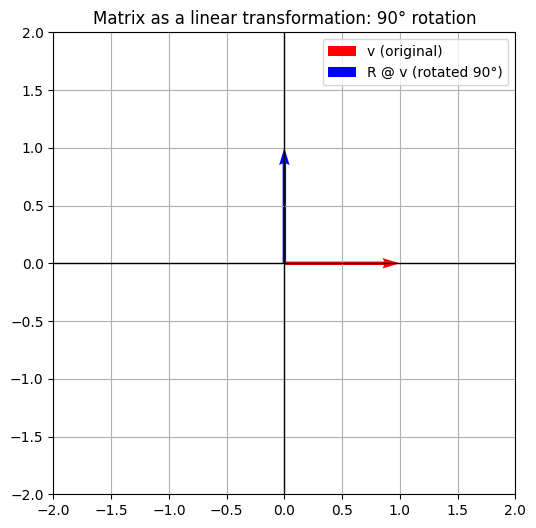

In [13]:


A = np.array([[2, 1],
              [0, 3]])

v = np.array([3, 4])

# Direct computation
print("A @ v =", A @ v)

# Row-by-row view
row1_dot = np.dot(A[0], v)
row2_dot = np.dot(A[1], v)
print("Row view:    [", row1_dot, ",", row2_dot, "]")

# Column-picture view: linear combination of A's columns
col1 = A[:, 0]
col2 = A[:, 1]
result = v[0] * col1 + v[1] * col2
print("Column view:", result)


# Non-commutavity 

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[0, 1],
              [1, 0]])

print("\nA @ B:")
print(A @ B)

print("\nB @ A:")
print(B @ A)

print("\nA @ B equals B @ A?", np.array_equal(A @ B, B @ A))



# 90° counterclockwise rotation matrix
R = np.array([[0, -1],
              [1,  0]])

# Start with a vector pointing right
v = np.array([1, 0])
v_rotated = R @ v

print("\nOriginal v:", v)
print("R @ v     :", v_rotated)

# Visualize using matplotlib
plt.figure(figsize=(6, 6))
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
           color='red', label='v (original)')
plt.quiver(0, 0, v_rotated[0], v_rotated[1], angles='xy', scale_units='xy', scale=1,
           color='blue', label='R @ v (rotated 90°)')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title('Matrix as a linear transformation: 90° rotation')
plt.show()

# The plot shows the same vector before and after applying R. The red arrow points
# right (along the x-axis), and the blue arrow points up (along the y-axis) — exactly
# what a 90° counterclockwise rotation should do. The matrix R encodes the entire
# rotation operation, and `R @ v` mechanically applies it to any vector.

# This same operation, on much larger scales, is what neural networks do: every
# layer multiplies an input vector by a weight matrix, transforming the input into
# a new representation. The matrix is the recipe; the vector is the data being
# transformed.

## 3. Identity, Inverse, and Determinant

These three concepts answer one question: **can a transformation be undone, and
what does it do to space?**

### Identity matrix (I)

The "do nothing" transformation. A square matrix with 1s on the diagonal and 0s
elsewhere. For any matrix A, `A @ I = I @ A = A`. The identity matrix plays the
same role for matrices that the number 1 plays for ordinary multiplication.

### Inverse matrix (A⁻¹)

The transformation that **undoes** A. Defined by:

> `A @ A⁻¹ = A⁻¹ @ A = I`

If A rotates 30° counterclockwise, A⁻¹ rotates 30° clockwise. If A scales by 2,
A⁻¹ scales by 0.5. Not every matrix has an inverse — only those whose
transformation doesn't lose information by collapsing space.

### Determinant (det A)

A single number that captures how much the transformation **scales area (in 2D)
or volume (in 3D)**:

- `det = 2` → areas double
- `det = 0.5` → areas halve
- `det = 1` → areas preserved (rotations, shears)
- `det = -1` → areas preserved but space is flipped (reflection)
- `det = 0` → space gets squished onto a lower dimension — no inverse exists

### The connection that ties everything together

A square matrix is **singular** (non-invertible) if and only if its determinant
is zero, which is equivalent to it being rank-deficient. These are all the same
property viewed differently:

> **A is invertible** ↔ **det(A) ≠ 0** ↔ **rank(A) = n** ↔ **A doesn't collapse space**

The same idea — does the transformation preserve all directions, or does it
destroy some of them — shows up in every diagnostic tool linear algebra gives you.

In [19]:

A = np.array([[2, 3],
              [4, 5]])

I = np.eye(2)
print("Identity matrix:")
print(I)

print("\nA @ I:")
print(A @ I)

print("\nDoes A @ I equal A?", np.array_equal(A @ I, A))


A_inv = np.linalg.inv(A)
# Verify: A @ A⁻¹ should be the identity
print("\nA @ A⁻¹:")
print(A @ A_inv)
print("\nClose to identity?", np.allclose(A @ A_inv, np.eye(2)))


# Singular matrix is Det(A) = 0 and these amtrix are non-invertible
# This matrix is singular because row 2 = 2 × row 1
S = np.array([[1, 2],
              [2, 4]])

print(f"\ndet(S) = {np.linalg.det(S):.4f}")
print(f"rank(S) = {np.linalg.matrix_rank(S)}")

# Trying to invert it fails
try:
    S_inv = np.linalg.inv(S)
    print("Inverse:", S_inv)
except np.linalg.LinAlgError as e:
    print(f"Cannot invert: {e}")

# The singular matrix S has determinant 0, rank 1 (less than its dimension), and
# no inverse. All three diagnostics tell the same story: applying S collapses 2D
# space onto a single line, destroying information about where points came from.
# A collapse can never be undone, which is why no inverse exists.

# These three concepts — determinant, rank, and invertibility — are the
# algebraic tools for detecting whether a transformation is "well-behaved"
# (reversible) or "degenerate" (collapsing). They show up constantly in real ML
# workflows whenever a system of equations needs to be solved.    

Identity matrix:
[[1. 0.]
 [0. 1.]]

A @ I:
[[2. 3.]
 [4. 5.]]

Does A @ I equal A? True

A @ A⁻¹:
[[1. 0.]
 [0. 1.]]

Close to identity? True

det(S) = 0.0000
rank(S) = 1
Cannot invert: Singular matrix


## 4. Solving Linear Systems

Many problems in math, science, and machine learning reduce to a single
question: given a matrix A and a vector b, find a vector x such that
`A @ x = b`. This is the heart of linear regression, factor models, and
much of classical numerical analysis.

### The Gaussian elimination procedure

To solve `A @ x = b` by hand, combine A and b into an augmented matrix
`[A | b]`, then use **row operations** to reduce it to **row echelon form**
(a "staircase" pattern of zeros below each leading entry). Once in this
form, back-substitution gives the solution.

The three legal row operations don't change the solution set:
1. Swap two rows
2. Multiply a row by a non-zero scalar
3. Add a multiple of one row to another

### Three possible outcomes

A linear system has exactly one of three behaviors, and you can diagnose
which by comparing ranks:

- **Unique solution** — `rank(A) = rank([A | b]) = n` (number of unknowns).
  A is invertible, b is reachable, and there's exactly one x.
- **No solution** — `rank(A) < rank([A | b])`. b lies outside what A can
  produce. The system is inconsistent.
- **Infinitely many solutions** — `rank(A) = rank([A | b]) < n`. A is
  rank-deficient but b is reachable. There are free parameters in the
  solution.

This is the **Rouché–Capelli theorem**, and it's the geometric reason these
three cases are the only possibilities.

### Solving in practice

In numpy, `np.linalg.solve(A, b)` runs Gaussian elimination under the hood
and returns the unique solution when one exists. For singular or
non-square systems, `np.linalg.lstsq(A, b, rcond=None)` returns the
**best approximate** solution (the one minimizing `‖A @ x - b‖²`).

It's much better to use `np.linalg.solve(A, b)` than to compute
`np.linalg.inv(A) @ b` — `solve` is faster and numerically more stable.

In [23]:
# Unique solution

# 2x + 3y = 7
# 4x - y = 1
A = np.array([[2, 3],
              [4, -1]])
b = np.array([7, 1])

x = np.linalg.solve(A, b)
print(f"\nSolution: x = {x[0]:.4f}, y = {x[1]:.4f}")

# Verify
print(f"\nA @ x = {A @ x}")
print(f"b     = {b}")
print(f"Match? {np.allclose(A @ x, b)}")


# Diagnosing the system out of the three cases where it falls

def diagnose_system(A, b):
    """Diagnose whether a linear system has unique, no, or infinite solutions."""
    rank_A = np.linalg.matrix_rank(A)
    rank_aug = np.linalg.matrix_rank(np.column_stack([A, b]))
    n = A.shape[1]
    
    print(f"  rank(A) = {rank_A}, rank([A|b]) = {rank_aug}, unknowns = {n}")
    
    if rank_A < rank_aug:
        print("  → NO SOLUTION (system is inconsistent)")
    elif rank_A == rank_aug == n:
        print("  → UNIQUE SOLUTION")
    else:
        print(f"  → INFINITELY MANY SOLUTIONS ({n - rank_A} free parameter(s))")


# Unique solution
print("\nSystem 1 (unique):")
diagnose_system(np.array([[2, 3], [4, -1]]), np.array([7, 1]))

# No solution (inconsistent)
print("\nSystem 2 (no solution):")
diagnose_system(np.array([[1, 1], [2, 2]]), np.array([3, 10]))

# Infinitely many solutions
print("\nSystem 3 (infinite):")
diagnose_system(np.array([[1, 1], [2, 2]]), np.array([3, 6]))


# The three solution behaviors aren't arbitrary — they reflect a deep
# geometric fact:

# - A linear system has a solution **only when b lies in the column space of A**
#   (the set of vectors A can produce).
# - The solution is unique **only when A's columns are linearly independent**
#   (no direction is redundant or collapsed).

# The Rouché–Capelli theorem packages these conditions into the simple rank
# comparison shown in `diagnose_system`. Once you internalize it, you can
# look at any linear system and predict its solution behavior before even
# trying to solve.



Solution: x = 0.7143, y = 1.8571

A @ x = [7. 1.]
b     = [7 1]
Match? True

System 1 (unique):
  rank(A) = 2, rank([A|b]) = 2, unknowns = 2
  → UNIQUE SOLUTION

System 2 (no solution):
  rank(A) = 1, rank([A|b]) = 2, unknowns = 2
  → NO SOLUTION (system is inconsistent)

System 3 (infinite):
  rank(A) = 1, rank([A|b]) = 1, unknowns = 2
  → INFINITELY MANY SOLUTIONS (1 free parameter(s))


## 5. Eigenvalues and Eigenvectors

Eigenvalues and eigenvectors reveal a transformation's **natural axes** — the
directions where it acts in its simplest possible form (pure scaling, no
rotation). They're the conceptual climax of Week 2 because they unify
everything from earlier days: rank, determinant, invertibility, and the
notion of "what does this transformation actually do?"

### The defining equation

A non-zero vector `v` is an **eigenvector** of `A` if applying `A` to it only
scales it — doesn't rotate or shear it off its original line:

> `A @ v = λ · v`

The scalar `λ` is the corresponding **eigenvalue** — the stretch factor.

### Geometric meaning

Most vectors get rotated or sheared when a matrix acts on them. **Eigenvectors
are the special ones that stay on their original line** — they only get
scaled (or flipped). The eigenvalue tells you by how much:

- `λ > 1` → stretched
- `0 < λ < 1` → compressed
- `λ = 1` → unchanged
- `λ < 0` → flipped (and scaled by `|λ|`)
- `λ = 0` → collapsed to the origin (matrix is singular)

### How to find them

The eigenvalues satisfy the **characteristic equation**:

> `det(A − λI) = 0`

Solving this polynomial in λ gives the eigenvalues. For each eigenvalue, the
corresponding eigenvector is found by solving:

> `(A − λI) @ v = 0`

### Why this connects to everything else

For any square matrix:

- **det(A) = product of eigenvalues.** If any eigenvalue is 0, det = 0.
- **A is singular ↔ 0 is an eigenvalue.** The zero eigenvalue's eigenvector
  is the direction that gets collapsed.
- **Diagonal matrices** are the easy case: their eigenvalues are the diagonal
  entries, and the eigenvectors are the standard basis vectors.
- **Rotation matrices** have **complex eigenvalues** — geometrically,
  rotations preserve no real direction, so no real eigenvectors

Eigenvalues: [5. 2.]

Eigenvectors (as columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

λ = 5.0000
  A @ v = [3.53553391 3.53553391]
  λ * v = [3.53553391 3.53553391]
  Equal? True


λ = 2.0000
  A @ v = [-0.89442719  1.78885438]
  λ * v = [-0.89442719  1.78885438]
  Equal? True



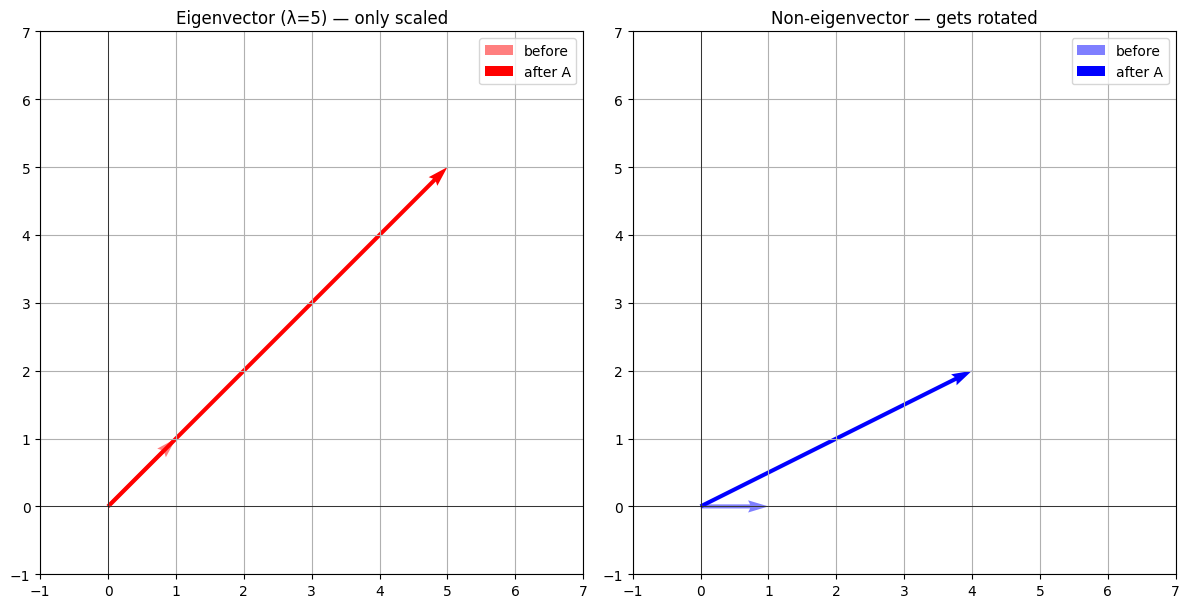

Eigenvalues of S: [0. 5.]
Is Determinant of S zero ? True
Any eigenvalue zero? True


In [32]:
# Computing eigen values and eigen vectors

A = np.array([[4, 1],
              [2, 3]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("\nEigenvectors (as columns):")
print(eigenvectors)


# Verfiy the defining equation
# A @ v = λ · v

for i in range(len(eigenvalues)):
    λ = eigenvalues[i]
    v = eigenvectors[:, i]
    
    left  = A @ v
    right = λ * v
    
    print(f"\nλ = {λ:.4f}")
    print(f"  A @ v = {left}")
    print(f"  λ * v = {right}")
    print(f"  Equal? {np.allclose(left, right)}\n")


# Visualzie eigen vectors stay on their line
A = np.array([[4, 1],
              [2, 3]])

# Eigenvectors of A (using clean paper representatives)
v_eigen = np.array([1, 1])      # eigenvalue = 5
v_nonei = np.array([1, 0])      # not an eigenvector

# Apply A
Av_eigen = A @ v_eigen
Av_nonei = A @ v_nonei

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Eigenvector — stays on its line
axes[0].quiver(0, 0, v_eigen[0], v_eigen[1], angles='xy', scale_units='xy',
               scale=1, color='red', alpha=0.5, label='before')
axes[0].quiver(0, 0, Av_eigen[0], Av_eigen[1], angles='xy', scale_units='xy',
               scale=1, color='red', label='after A')
axes[0].set_title('Eigenvector (λ=5) — only scaled')
axes[0].set_xlim(-1, 7)
axes[0].set_ylim(-1, 7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].legend()

# Non-eigenvector — rotates off its line
axes[1].quiver(0, 0, v_nonei[0], v_nonei[1], angles='xy', scale_units='xy',
               scale=1, color='blue', alpha=0.5, label='before')
axes[1].quiver(0, 0, Av_nonei[0], Av_nonei[1], angles='xy', scale_units='xy',
               scale=1, color='blue', label='after A')
axes[1].set_title('Non-eigenvector — gets rotated')
axes[1].set_xlim(-1, 7)
axes[1].set_ylim(-1, 7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_aspect('equal')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Detecting singularity via eigen values

# Singular matrix
S = np.array([[1, 2],
              [2, 4]])

eigenvalues = np.linalg.eigvals(S)
print(f"Eigenvalues of S: {eigenvalues}")
print("Is Determinant of S zero ?", np.equal(np.linalg.det(S),0))
print(f"Any eigenvalue zero? {np.any(np.isclose(eigenvalues, 0))}")


In [ ]:
## Reflection — Week 2

Week 2 took the vector intuition from Week 1 and extended it to **whole
transformations of space**. Matrices stopped being abstract grids of numbers
and started behaving like operators that act on vectors — rotating them,
scaling them, sometimes collapsing them entirely.

A few moments stood out:

- **The column picture clicked.** Reading the columns of a matrix as
  "where the basis vectors land after the transformation" turned matrix-vector
  multiplication into something visual and intuitive. Once that landed,
  `A @ v` stopped feeling like a formula and started feeling like applying
  a recipe to a point.

- **Composition is real, but commutativity isn't.** Matrix multiplication
  combines two transformations into one. But the order matters: rotating then
  shearing produces a different result than shearing then rotating. This is
  why `AB ≠ BA` in general — the transformations are doing different things
  in different orders.

- **Several different concepts turn out to be the same.** A matrix being
  singular, having zero determinant, being rank-deficient, having no inverse,
  and having a zero eigenvalue are all **the same property** seen from
  different angles. By Day 5, what looked like five different diagnostics
  was clearly one geometric fact dressed in different math.

- **Eigenvalues reveal the natural axes of a transformation.** They tell you
  the directions where a matrix acts in its simplest possible form (pure
  stretching, no rotation). For a real-world dataset's covariance matrix,
  the eigenvalues also reveal how "low-dimensional" the data actually is —
  the foundation of PCA, which comes later.

The biggest takeaway: linear algebra has surprisingly few independent ideas.
Most of what looks like a different concept is just a different vocabulary
for the same geometric phenomenon. Once you internalize what a transformation
does to space, the algebraic machinery follows naturally.

### What's next

**Week 3** will go deeper on matrix decompositions — particularly SVD
(singular value decomposition), the workhorse behind dimensionality reduction,
recommendation systems, and many other applied techniques. After that,
Phase 1 continues with calculus and probability before circling back to
build real ML models from scratch in Phase 2.